In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

def sigmoid(z):
    """Сигмоидная функция"""
    return 1 / (1 + np.exp(-z))

def log_loss(w, X, y):
    """
    Вычисляет логистическую функцию потерь и градиент
    
    Параметры:
    w - вектор весов (включая w0 для смещения)
    X - матрица признаков (с добавленным столбцом единиц для смещения)
    y - вектор истинных меток (0 или 1)
    
    Возвращает:
    loss - значение функции потерь
    grad - градиент функции потерь
    """
    n_samples = X.shape[0]
    
    # Вычисляем линейную комбинацию
    z = np.dot(X, w)
    
    # Применяем сигмоидную функцию
    predictions = sigmoid(z)
    
    # Вычисляем функцию потерь (бинарная кросс-энтропия)
    # Добавляем небольшое значение epsilon для численной стабильности
    epsilon = 1e-15
    predictions = np.clip(predictions, epsilon, 1 - epsilon)
    
    loss = -np.mean(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))
    
    # Вычисляем градиент
    grad = (1 / n_samples) * np.dot(X.T, (predictions - y))
    
    return loss, grad

def optimize(w, X, y, n_iterations, eta):
    """
    Оптимизация весов с помощью градиентного спуска
    
    Параметры:
    w - начальные веса
    X - матрица признаков
    y - вектор меток
    n_iterations - количество итераций
    eta - скорость обучения
    
    Возвращает:
    w - оптимизированные веса
    losses - список значений функции потерь на каждой итерации
    """
    losses = []
    
    for i in range(n_iterations):
        # Вычисляем функцию потерь и градиент
        loss, grad = log_loss(w, X, y)
        
        # Обновляем веса
        w = w - eta * grad
        
        # Сохраняем значение функции потерь
        losses.append(loss)
        
        # Выводим прогресс каждые 100 итераций
        if i % 100 == 0:
            print(f"Итерация {i}: loss = {loss:.4f}")
    
    return w, losses

def predict(w, X, b=0.5):
    """
    Предсказание классов
    
    Параметры:
    w - вектор весов
    X - матрица признаков (с добавленным столбцом единиц)
    b - порог классификации (по умолчанию 0.5)
    
    Возвращает:
    y_predicted - предсказанные метки классов (0 или 1)
    """
    # Вычисляем линейную комбинацию
    z = np.dot(X, w)
    
    # Применяем сигмоидную функцию
    probabilities = sigmoid(z)
    
    # Применяем порог для классификации
    y_predicted = (probabilities >= b).astype(int)
    
    return y_predicted, probabilities

Начинаем обучение...
Начальные веса: [ 0.00496714 -0.00138264  0.00647689]
Итерация 0: loss = 0.6939
Итерация 100: loss = 0.3157
Итерация 200: loss = 0.2931
Итерация 300: loss = 0.2869
Итерация 400: loss = 0.2845
Итерация 500: loss = 0.2834
Итерация 600: loss = 0.2827
Итерация 700: loss = 0.2823
Итерация 800: loss = 0.2820
Итерация 900: loss = 0.2818

Оптимизированные веса: [ 0.42136788  2.79715396 -0.15962372]
Финальная функция потерь: 0.2817

Точность на обучающей выборке: 0.8862
Точность на тестовой выборке: 0.8700


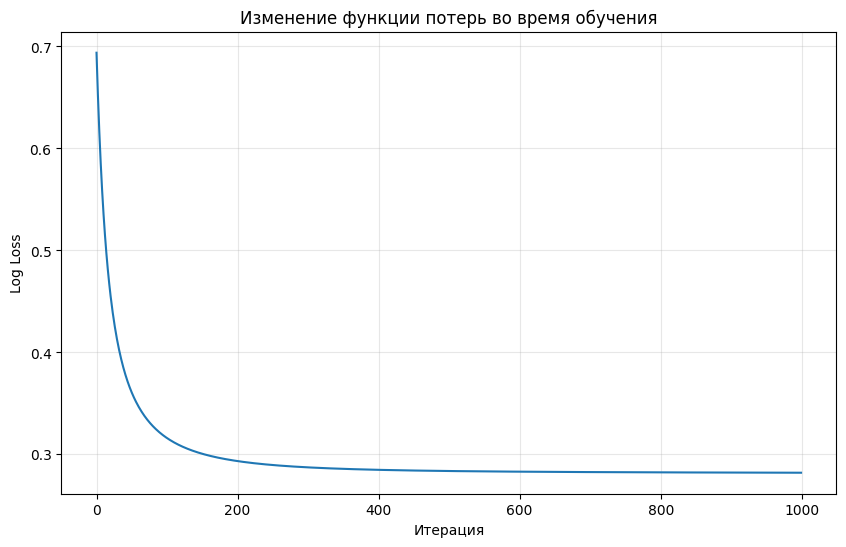


Визуализация разделяющей границы на обучающей выборке:


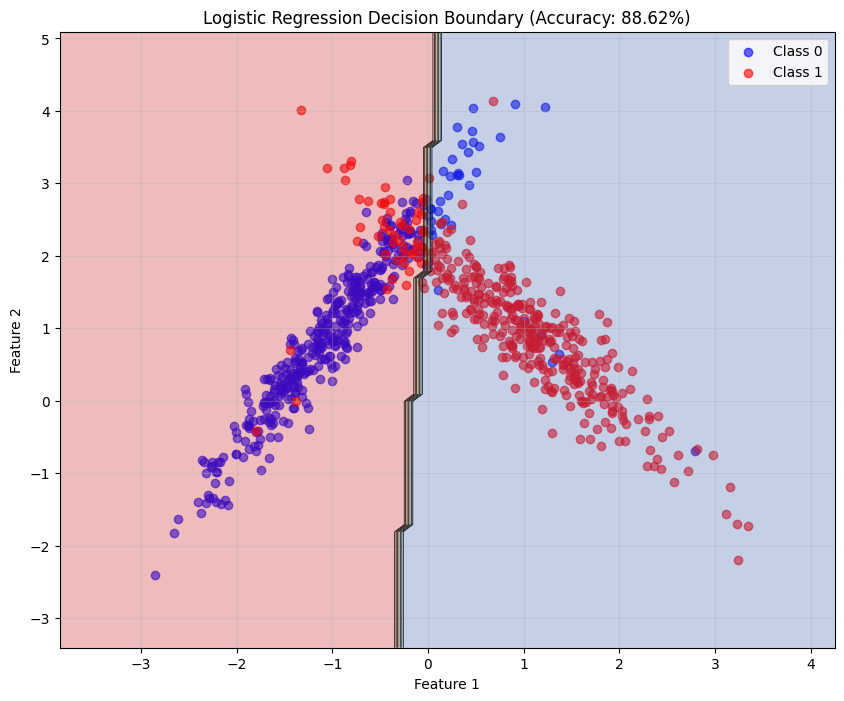

In [3]:
# ==================== ЭКСПЕРИМЕНТ ====================

# Генерация синтетических данных
np.random.seed(42)
X, y = make_classification(
    n_samples=1000,      # всего объектов
    n_features=2,        # количество признаков
    n_informative=2,     # информативных признаков
    n_redundant=0,       # избыточных признаков
    n_clusters_per_class=1,  # количество кластеров на класс
    flip_y=0.05,         # доля шума
    random_state=42
)

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Добавляем столбец единиц для смещения (bias term)
X_train_bias = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_bias = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# Инициализация весов
n_features = X_train_bias.shape[1]
w_initial = np.random.randn(n_features) * 0.01

# Параметры обучения
n_iterations = 1000
eta = 0.1  # скорость обучения

print("Начинаем обучение...")
print(f"Начальные веса: {w_initial}")

# Обучение модели
w_optimized, losses = optimize(w_initial, X_train_bias, y_train, n_iterations, eta)

print(f"\nОптимизированные веса: {w_optimized}")
print(f"Финальная функция потерь: {losses[-1]:.4f}")

# Предсказание на тестовой выборке
y_pred_test, prob_test = predict(w_optimized, X_test_bias)
y_pred_train, prob_train = predict(w_optimized, X_train_bias)

# Оценка качества модели
def accuracy_score(y_true, y_pred):
    """Вычисление точности"""
    return np.mean(y_true == y_pred)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"\nТочность на обучающей выборке: {train_accuracy:.4f}")
print(f"Точность на тестовой выборке: {test_accuracy:.4f}")

# Визуализация изменения функции потерь
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Изменение функции потерь во время обучения')
plt.xlabel('Итерация')
plt.ylabel('Log Loss')
plt.grid(True, alpha=0.3)
plt.show()

# Визуализация разделяющей границы
def plot_decision_boundary(X, y, w, title):
    """Визуализация данных и разделяющей границы"""
    plt.figure(figsize=(10, 8))
    
    # Разделяем точки по классам
    class_0 = X[y == 0]
    class_1 = X[y == 1]
    
    plt.scatter(class_0[:, 0], class_0[:, 1], color='blue', alpha=0.6, label='Class 0')
    plt.scatter(class_1[:, 0], class_1[:, 1], color='red', alpha=0.6, label='Class 1')
    
    # Создаем сетку для отображения границы
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    # Вычисляем предсказания для всех точек сетки
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_points_bias = np.c_[np.ones((grid_points.shape[0], 1)), grid_points]
    Z, _ = predict(w, grid_points_bias)
    Z = Z.reshape(xx.shape)
    
    # Отображаем разделяющую границу
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    plt.contour(xx, yy, Z, colors='black', linewidths=0.5)
    
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

print("\nВизуализация разделяющей границы на обучающей выборке:")
plot_decision_boundary(X_train, y_train, w_optimized, 
                      f'Logistic Regression Decision Boundary (Accuracy: {train_accuracy:.2%})')


ИССЛЕДОВАНИЕ ВЛИЯНИЯ ПАРАМЕТРОВ
Итерация 0: loss = 0.6944
Итерация 100: loss = 0.6730
Итерация 0: loss = 0.6897
Итерация 100: loss = 0.5348
Итерация 0: loss = 0.6954
Итерация 100: loss = 0.3157
Итерация 0: loss = 0.7023
Итерация 100: loss = 0.2833
Итерация 0: loss = 0.6979
Итерация 100: loss = 0.2817


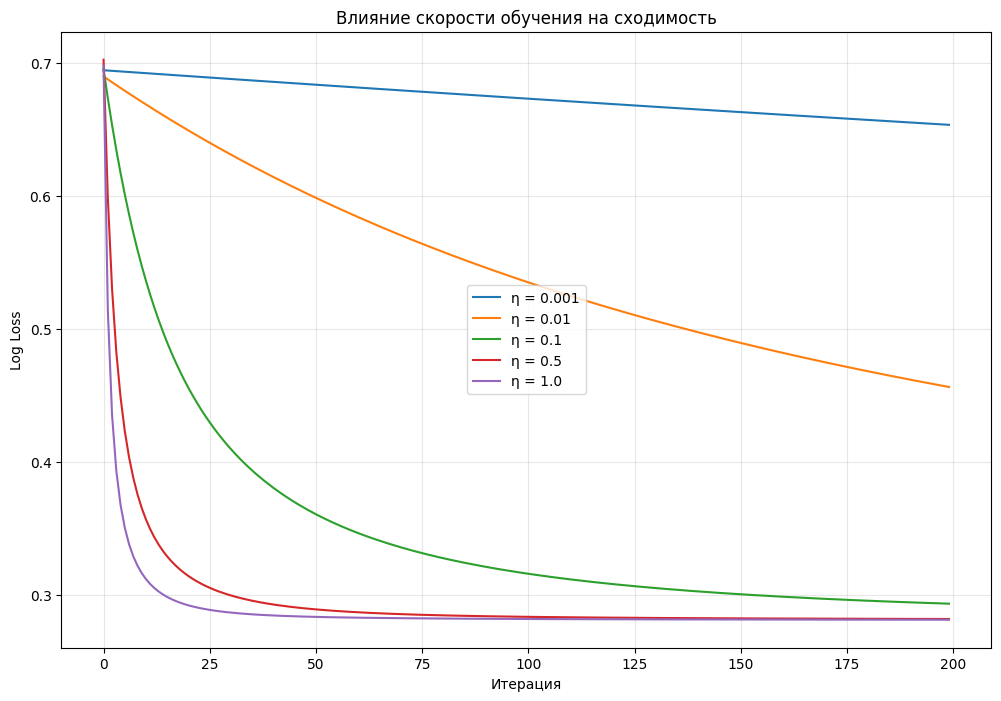

Итерация 0: loss = 0.6998
Итерация 0: loss = 0.6929
Итерация 0: loss = 0.6927
Итерация 100: loss = 0.3157
Итерация 200: loss = 0.2931
Итерация 300: loss = 0.2869
Итерация 400: loss = 0.2845
Итерация 0: loss = 0.6960
Итерация 100: loss = 0.3157
Итерация 200: loss = 0.2931
Итерация 300: loss = 0.2869
Итерация 400: loss = 0.2845
Итерация 500: loss = 0.2833
Итерация 600: loss = 0.2827
Итерация 700: loss = 0.2823
Итерация 800: loss = 0.2820
Итерация 900: loss = 0.2818
Итерация 0: loss = 0.6845
Итерация 100: loss = 0.3155
Итерация 200: loss = 0.2931
Итерация 300: loss = 0.2869
Итерация 400: loss = 0.2845
Итерация 500: loss = 0.2834
Итерация 600: loss = 0.2827
Итерация 700: loss = 0.2823
Итерация 800: loss = 0.2820
Итерация 900: loss = 0.2818
Итерация 1000: loss = 0.2817
Итерация 1100: loss = 0.2816
Итерация 1200: loss = 0.2815
Итерация 1300: loss = 0.2814
Итерация 1400: loss = 0.2813
Итерация 1500: loss = 0.2813
Итерация 1600: loss = 0.2812
Итерация 1700: loss = 0.2812
Итерация 1800: loss = 

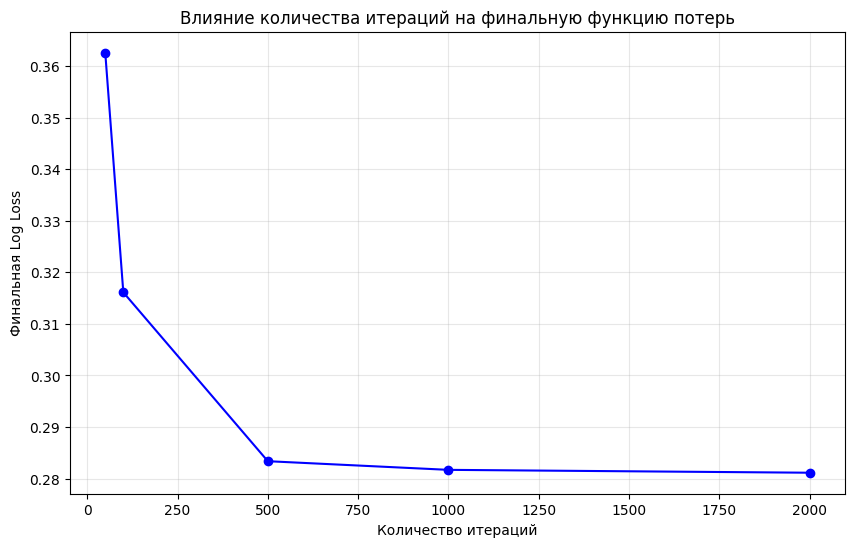


ОТВЕТЫ НА ДОПОЛНИТЕЛЬНЫЕ ВОПРОСЫ

1. Как влияет размер шага eta на сходимость алгоритма?
   - Слишком маленький η: алгоритм сходится очень медленно, требуется много итераций
   - Слишком большой η: алгоритм может расходиться или колебаться вокруг минимума
   - Оптимальный η: обеспечивает быструю и стабильную сходимость к минимуму

2. Что произойдет, если выбрать слишком маленькое или слишком большое количество итераций n_iterations?
   - Слишком мало итераций: модель не успеет сойтись к оптимуму, будет недообучена
   - Слишком много итераций: риск переобучения, бесполезные вычисления после сходимости
   - Оптимально: использовать раннюю остановку по валидационной выборке

3. Почему логистическая регрессия подходит для задач только бинарной классификации?
   - Логистическая регрессия использует сигмоидную функцию, которая выдает вероятность 
     принадлежности к одному классу (P(y=1|x))
   - Для многоклассовой классификации нужно использовать расширения:
     * One-vs-Rest (OvR) - нес

In [4]:
# ==================== ИССЛЕДОВАНИЕ ВЛИЯНИЯ ПАРАМЕТРОВ ====================

print("\n" + "="*60)
print("ИССЛЕДОВАНИЕ ВЛИЯНИЯ ПАРАМЕТРОВ")
print("="*60)

# Исследуем влияние скорости обучения
etas = [0.001, 0.01, 0.1, 0.5, 1.0]
plt.figure(figsize=(12, 8))

for eta in etas:
    w_temp = np.random.randn(n_features) * 0.01
    _, losses_temp = optimize(w_temp, X_train_bias, y_train, 200, eta)
    plt.plot(losses_temp, label=f'η = {eta}')

plt.title('Влияние скорости обучения на сходимость')
plt.xlabel('Итерация')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Исследуем влияние количества итераций
iterations_list = [50, 100, 500, 1000, 2000]
final_losses = []

for n_iter in iterations_list:
    w_temp = np.random.randn(n_features) * 0.01
    _, losses_temp = optimize(w_temp, X_train_bias, y_train, n_iter, 0.1)
    final_losses.append(losses_temp[-1])
    
plt.figure(figsize=(10, 6))
plt.plot(iterations_list, final_losses, 'bo-')
plt.title('Влияние количества итераций на финальную функцию потерь')
plt.xlabel('Количество итераций')
plt.ylabel('Финальная Log Loss')
plt.grid(True, alpha=0.3)
plt.show()

# ==================== ОТВЕТЫ НА ВОПРОСЫ ====================

print("\n" + "="*60)
print("ОТВЕТЫ НА ДОПОЛНИТЕЛЬНЫЕ ВОПРОСЫ")
print("="*60)

print("""
1. Как влияет размер шага eta на сходимость алгоритма?
   - Слишком маленький η: алгоритм сходится очень медленно, требуется много итераций
   - Слишком большой η: алгоритм может расходиться или колебаться вокруг минимума
   - Оптимальный η: обеспечивает быструю и стабильную сходимость к минимуму

2. Что произойдет, если выбрать слишком маленькое или слишком большое количество итераций n_iterations?
   - Слишком мало итераций: модель не успеет сойтись к оптимуму, будет недообучена
   - Слишком много итераций: риск переобучения, бесполезные вычисления после сходимости
   - Оптимально: использовать раннюю остановку по валидационной выборке

3. Почему логистическая регрессия подходит для задач только бинарной классификации?
   - Логистическая регрессия использует сигмоидную функцию, которая выдает вероятность 
     принадлежности к одному классу (P(y=1|x))
   - Для многоклассовой классификации нужно использовать расширения:
     * One-vs-Rest (OvR) - несколько бинарных классификаторов
     * Multinomial Logistic Regression (Softmax Regression)
""")